In [64]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from spectral_cube import SpectralCube
from turbustat.simulator import make_ppv
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
from skimage.util import random_noise
import corner


In [65]:
# Add path to py_modules 

sys.path.append(str(Path().resolve().parents[0] / 'py_modules')) # 1 level up = project root
from turb_utils import make_extended, make_3dfield
import strucfunc
import bfunc
import bplot

In [3]:
# Physical parameters

r0 = 32.0
N = 256
m3D = 0.30
m2D = 1.2
sig_E = 1

# 3D 

# 2D

In [5]:
vmap2D = make_extended(N,
    powerlaw           = 2.0 + m2D,
    correlation_length = r0,  
  #  amp                = 1.0,                      No amp in 2D
    ellip              = 0.5,
    theta              = 45,
    randomseed         = 2025_10_01)#* u.km / u.s   No units in 2D


In [6]:
sig       = vmap2D.std()
vmap2D /= sig
print(sig)

2.4139769251917715


In [7]:
type(vmap2D)

numpy.ndarray

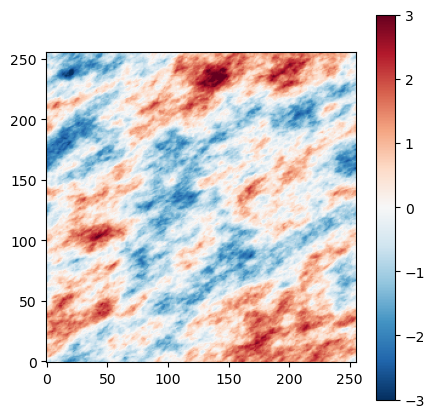

In [20]:


fig, ax = plt.subplots(
    1,
    1,
    #sharey=True,
    figsize=(5, 5),
)

imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap2D, **imshow_kwds)
fig.colorbar(im)

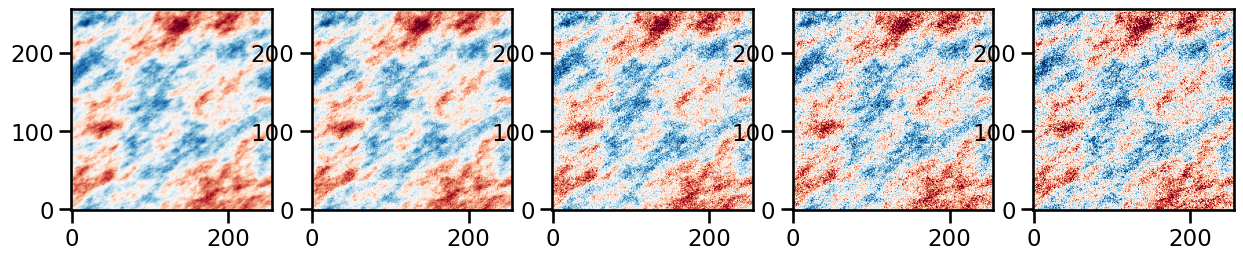

In [160]:
# Adding noise

noisy_0 = random_noise(vmap2D, mode='gaussian', var=0.01, clip =  False)  
noisy_1 = random_noise(vmap2D, mode='gaussian', var=0.1, clip =  False)  
noisy_2 = random_noise(vmap2D, mode='gaussian', var=0.5, clip =  False)  
noisy_3 = random_noise(vmap2D, mode='gaussian', var=0.75, clip =  False)  
noisy_4 = random_noise(vmap2D, mode='gaussian', var=1.0, clip =  False) 

fig, (a0,a1,a2,a3,a4) = plt.subplots(
    1,
    5,
    #sharey=True,
    figsize=(15, 5),
)

imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = a0.imshow(noisy_0, **imshow_kwds)
im = a1.imshow(noisy_1, **imshow_kwds)
im = a2.imshow(noisy_2, **imshow_kwds)
im = a3.imshow(noisy_3, **imshow_kwds)
im = a4.imshow(noisy_4, **imshow_kwds)

#fig.colorbar(im)

In [161]:
sf = strucfunc.strucfunc_numba_parallel(vmap2D, dlogr=0.05)
sf_noise_0 = strucfunc.strucfunc_numba_parallel(noisy_0, dlogr=0.05)
sf_noise_1 = strucfunc.strucfunc_numba_parallel(noisy_1, dlogr=0.05)
sf_noise_2 = strucfunc.strucfunc_numba_parallel(noisy_2, dlogr=0.05)
sf_noise_3 = strucfunc.strucfunc_numba_parallel(noisy_3, dlogr=0.05)
sf_noise_4 = strucfunc.strucfunc_numba_parallel(noisy_4, dlogr=0.05)

In [162]:

#rslt["Unweighted mean velocity"] = np.mean(vv[good])
#rslt["Unweighted sigma^2"] = np.var(vv[good])
#v0w = rslt["Weighted mean velocity"] = np.average(vv, weights=sb)
#rslt["Weighted sigma^2"] = np.average((vv - v0w)**2, weights=sb)
#b2 = rslt['Unweighted B(r)']
#b2w = rslt['Weighted B(r)']
#e_b2 = b2  *.1
#e_b2w = b2w  *.1
#s = 10**rslt['log10 r'] * data['pix'] * data['pc']
#e_s = s  *.1
#sig2 = rslt['Unweighted sigma^2']
#sig2w = rslt['Weighted sigma^2']
#sig = sig2**0.5



In [163]:
np.nanvar(sf['Unweighted B(r)'])

0.6922170081338871

In [164]:
sf['Unweighted B(r)'].var()

nan

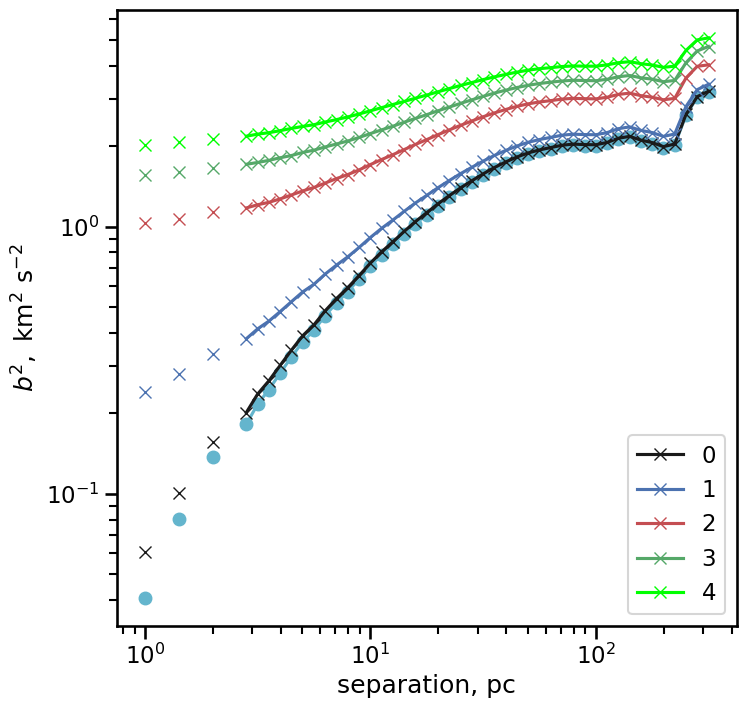

In [184]:
# Structure functions

fig, ax = plt.subplots(
    figsize=(8, 8),
)
ax.plot(10**sf['log10 r'], sf['Unweighted B(r)'], marker="o", color="c")
ax.plot(10**sf_noise_0['log10 r'], sf_noise_0['Unweighted B(r)'], marker="x", color="k", label = '0')
ax.plot(10**sf_noise_1['log10 r'], sf_noise_1['Unweighted B(r)'], marker="x", color="b", label = '1')
ax.plot(10**sf_noise_2['log10 r'], sf_noise_2['Unweighted B(r)'], marker="x", color="r", label = '2')
ax.plot(10**sf_noise_3['log10 r'], sf_noise_3['Unweighted B(r)'], marker="x", color="g", label = '3')
ax.plot(10**sf_noise_4['log10 r'], sf_noise_4['Unweighted B(r)'], marker="x", color="lime", label = '4')
ax.legend()

ax.set(xscale='log', yscale='log', 
       xlabel='separation, pc',
       ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$'
      )
None

# confidence intervals user def

In [175]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit

def fit_structure_function(
    data_in,
    N,
    bfunc,
    bplot,
    name='name',
    data='data',
    pc_per_arcsec=1,
    relative_uncertainty=0.07,
    emcee_steps=50000,
    emcee_burn=500,
    emcee_thin=50,
    emcee_workers=16,
):
    """
    Fits a structure function model to the input data and performs MCMC sampling.
    
    Parameters
    ----------
    sf_noise_2 : dict or DataFrame-like
        Must have keys: 'N pairs', 'Unweighted B(r)', 'log10 r'
    N : float
        Box size parameter.
    bfunc : module or object
        Must have attribute bfunc03s (model function).
    bplot : module or object
        Must provide corner_plot and strucfunc_plot functions.
    name : str
        Name identifier for plots.
    data : str
        Data identifier for plots.
    pc_per_arcsec : float
        Conversion factor for arcsec to pc.
    relative_uncertainty : float
        Relative uncertainty for weighting.
    emcee_steps : int
        Number of MCMC steps.
    emcee_burn : int
        Number of MCMC burn-in steps.
    emcee_thin : int
        MCMC thinning factor.
    emcee_workers : int
        Number of parallel workers for emcee.
    
    Returns
    -------
    results : dict
        Contains 'result' (LMFit minimize result) and 'result_emcee' (MCMC result).
    """

    # Mask valid data
    mask = np.array(data_in["N pairs"]) > 0
    B = np.array(data_in['Unweighted B(r)'])[mask]
    r = np.array(10 ** np.array(data_in['log10 r']))[mask]
    box_size = N

    # Model
    model = lmfit.Model(bfunc.bfunc03s)

    # Set parameter hints
    model.set_param_hint("r0", value=0.1 * box_size, min=0.01 * box_size, max=2.0 * box_size)
    model.set_param_hint("sig2", value=0.5 * B.max(), min=0.25 * B.max(), max=2.0 * B.max())
    model.set_param_hint("m", value=1.0, min=0.5, max=2.0)
    model.set_param_hint("s0", value=0.5 * pc_per_arcsec, min=0.1 * pc_per_arcsec, max=1.5 * pc_per_arcsec)
    model.set_param_hint("noise", value=0.5 * B.min(), min=0.0, max=3 * B.min())
    # model.set_param_hint("box_size", value=box_size, vary=False)

    # Weights
    weights = 1.0 / (relative_uncertainty * B)
    large_scale = r > 0.5 * box_size
    # Optional: weights[large_scale] /= 1.25
    # Optional: weights[:1] /= 2.0

    to_fit = r <= 0.6 * box_size
    result = model.fit(B[to_fit], weights=weights[to_fit], r=r[to_fit])

    # MCMC with emcee
    emcee_kws = dict(
        steps=emcee_steps,
        burn=emcee_burn,
        thin=emcee_thin,
        is_weighted=True,
        progress=False,
        workers=emcee_workers,
    )
    emcee_params = result.params.copy()
    # Optionally add lnsigma parameter here if needed

    result_emcee = model.fit(
        data=B[to_fit],
        r=r[to_fit],
        weights=weights[to_fit],
        params=emcee_params,
        method="emcee",
        nan_policy="omit",
        fit_kws=emcee_kws,
    )

    # Plot acceptance fraction
    plt.figure()
    plt.plot(result_emcee.acceptance_fraction, "o")
    plt.xlabel("walker")
    plt.ylabel("acceptance fraction")
    plt.title("MCMC Acceptance Fraction")
    plt.show()

    # Print autocorrelation times
    if hasattr(result_emcee, "acor"):
        print("Autocorrelation time for the parameters:")
        print("----------------------------------------")
        for i, p in enumerate(result_emcee.params):
            try:
                print(f"{p} = {result_emcee.acor[i]:.3f}")
            except IndexError:
                pass

    # Corner plot
    bplot.corner_plot(
        result_emcee, result, name, data, data_ranges=[0.95, 0.99, 0.995, 0.997, 0.999]
    )

    # Structure function plot
    bplot.strucfunc_plot(
        result_emcee, result, r, B, to_fit, name, data, box_size, large_scale
    )

    # Return fit results
    return {'result': result, 'result_emcee': result_emcee}


C:\Users\ZAINTEL2\anaconda3\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


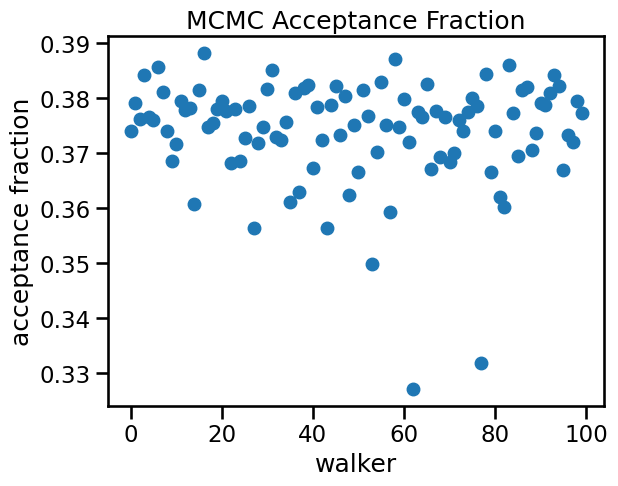

Autocorrelation time for the parameters:
----------------------------------------
r0 = 764.884
sig2 = 712.839
m = 246.840
s0 = 149.012
noise = 171.454


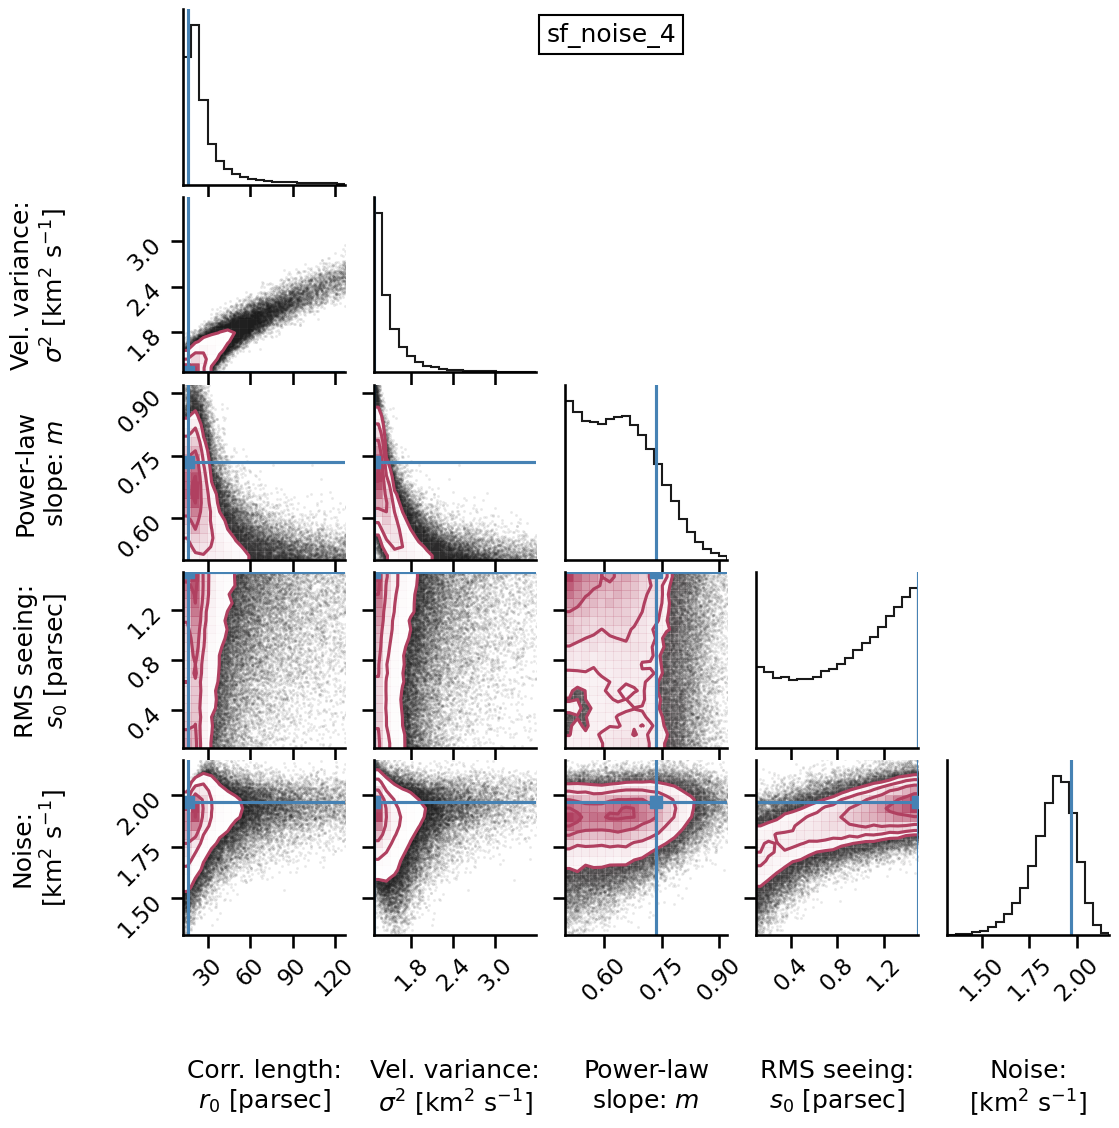

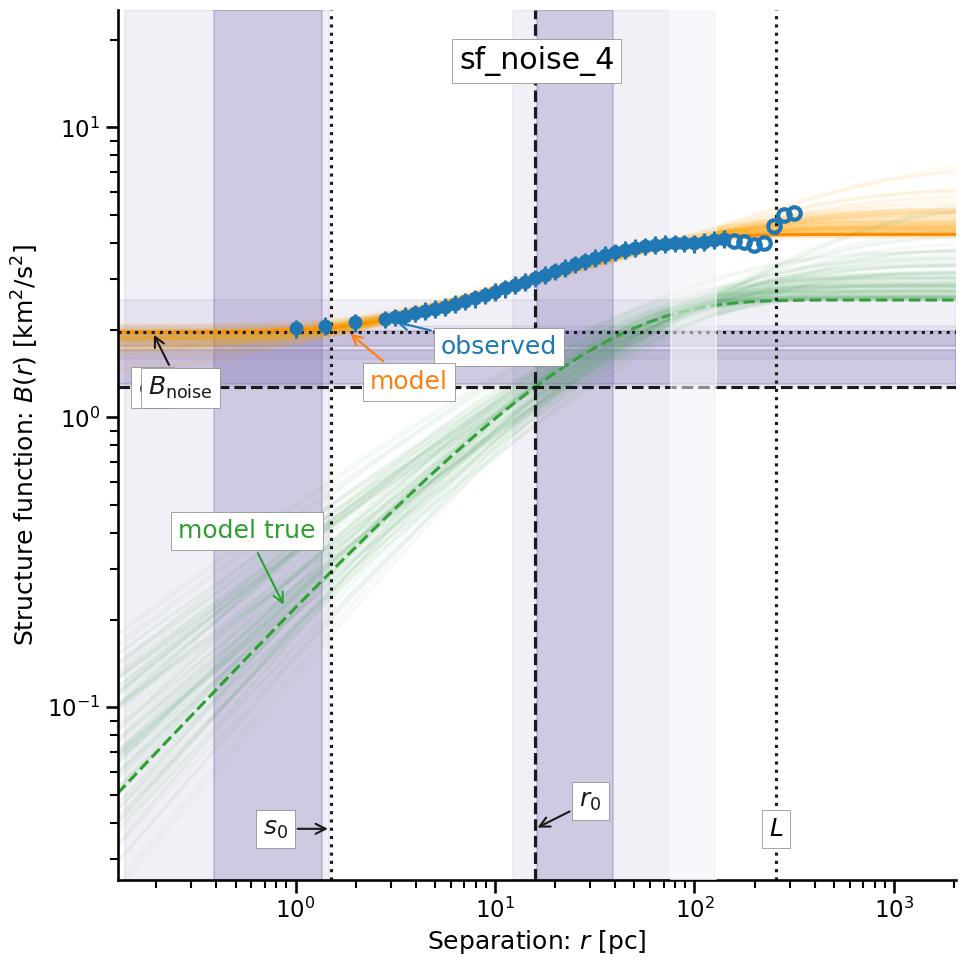

In [177]:
results = fit_structure_function(sf_noise_4, N=256, bfunc=bfunc, bplot=bplot, name = 'sf_noise_4', data = 'sf_noise_4')

C:\Users\ZAINTEL2\anaconda3\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


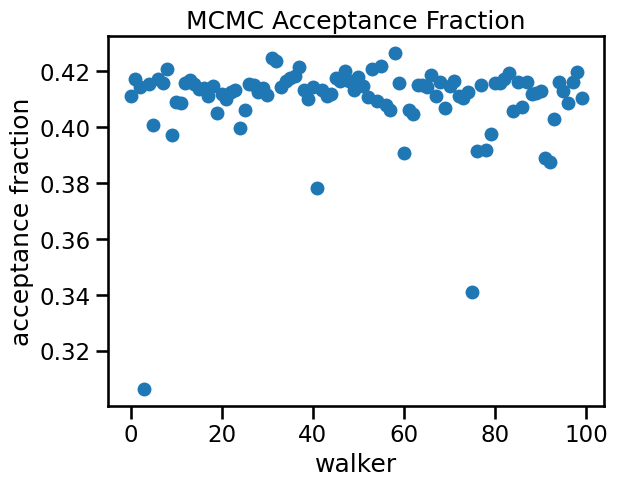

Autocorrelation time for the parameters:
----------------------------------------
r0 = 624.115
sig2 = 566.737
m = 230.125
s0 = 133.122
noise = 125.475


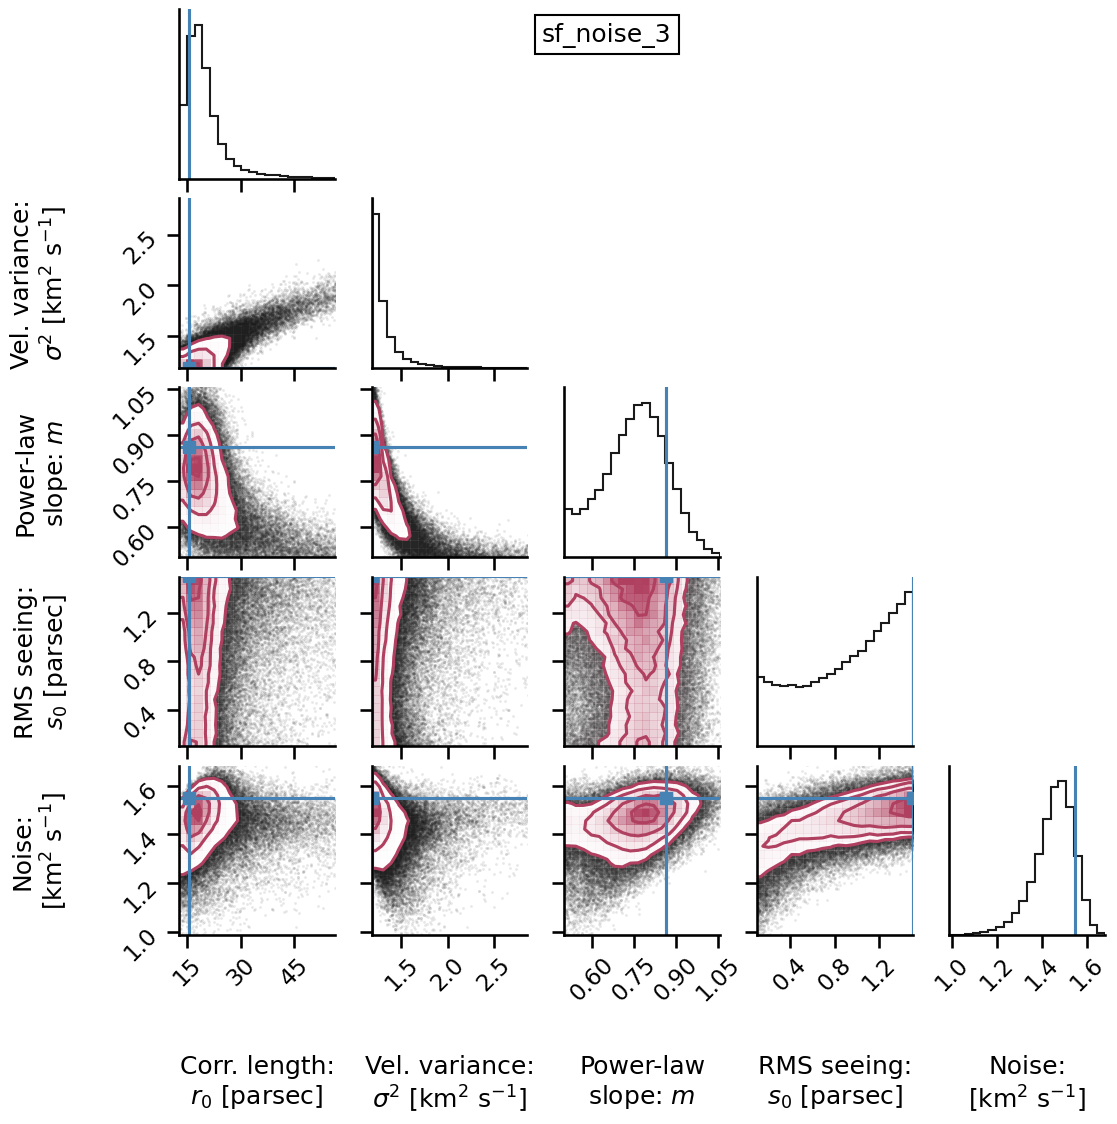

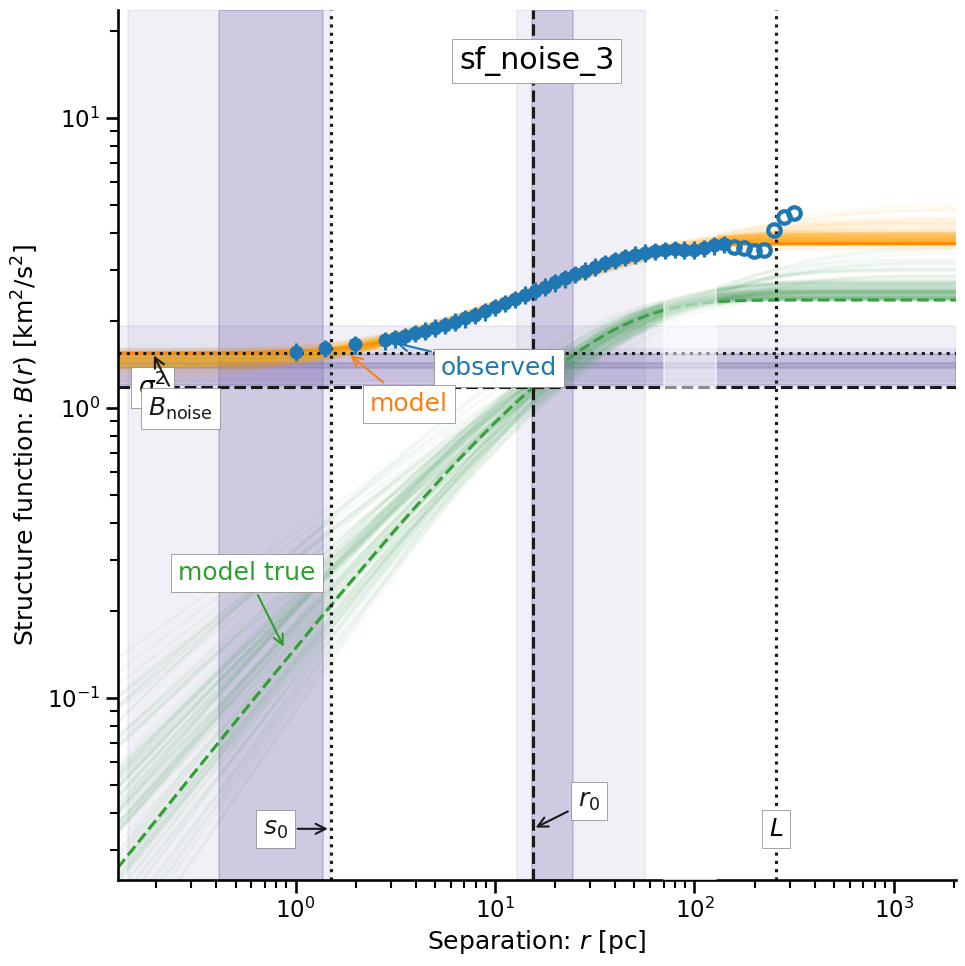

In [179]:
results = fit_structure_function(sf_noise_3, N=256, bfunc=bfunc, bplot=bplot, name = 'sf_noise_3', data = 'sf_noise_3')

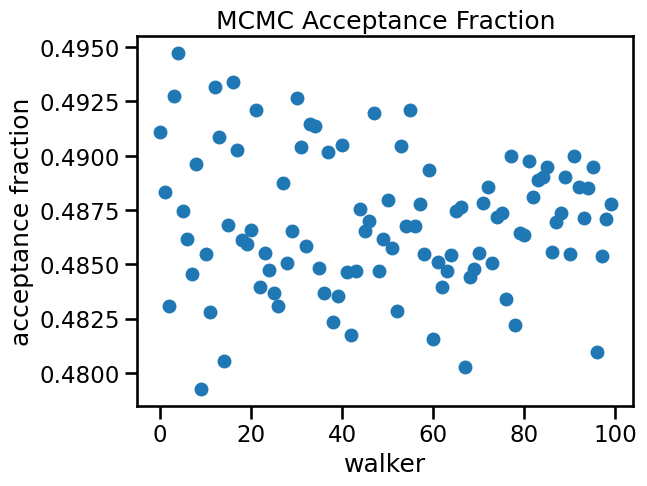

Autocorrelation time for the parameters:
----------------------------------------
r0 = 79.293
sig2 = 83.017
m = 78.712
s0 = 86.280
noise = 76.793


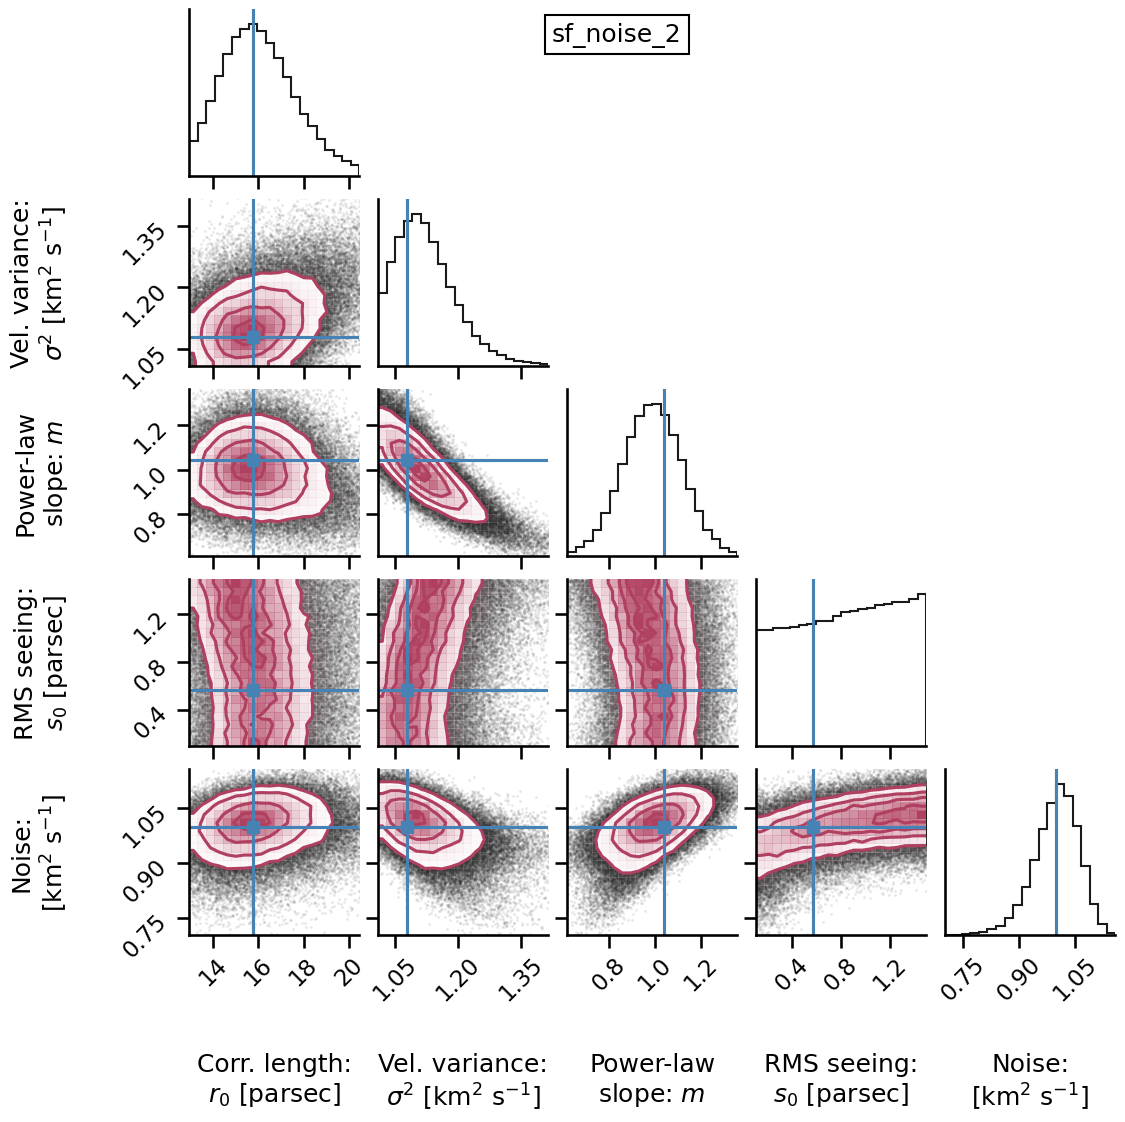

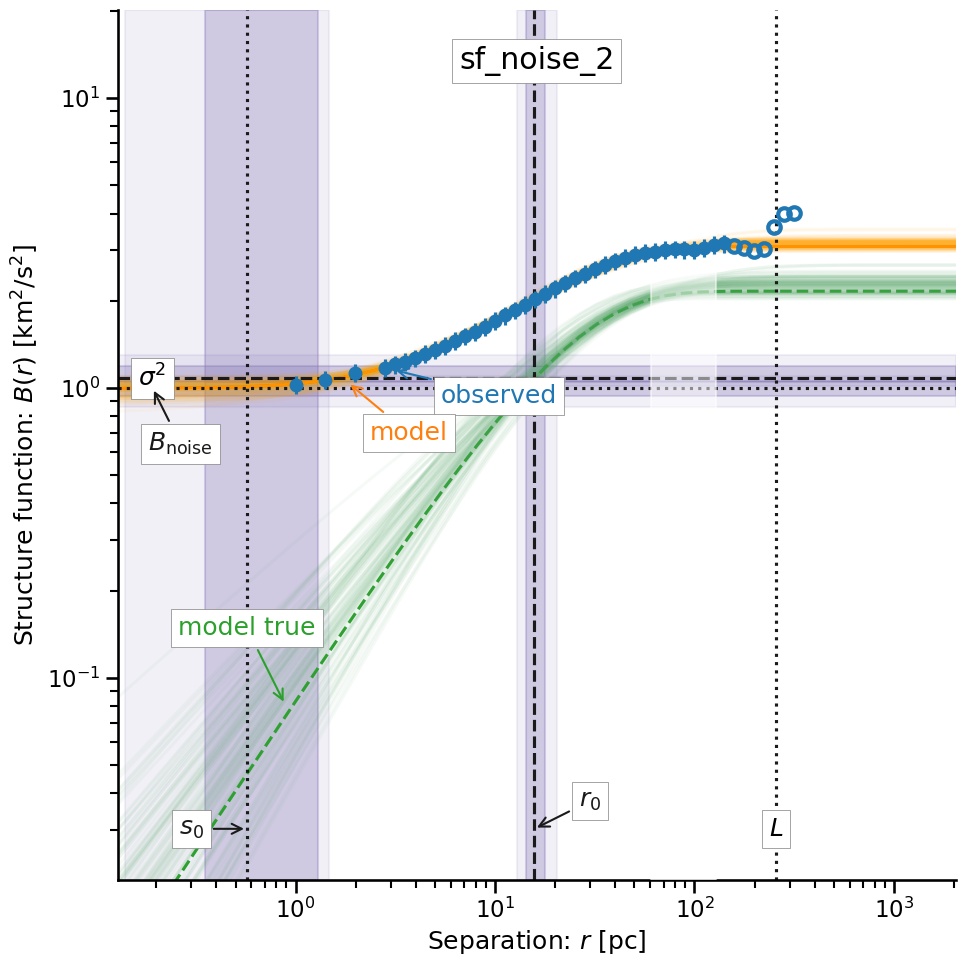

In [180]:
results = fit_structure_function(sf_noise_2, N=256, bfunc=bfunc, bplot=bplot, name = 'sf_noise_2', data = 'sf_noise_2')

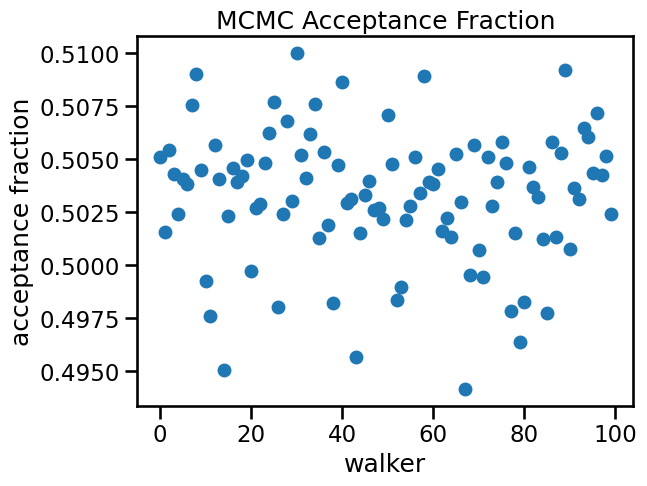

Autocorrelation time for the parameters:
----------------------------------------
r0 = 67.334
sig2 = 70.899
m = 70.816
s0 = 83.727
noise = 80.495


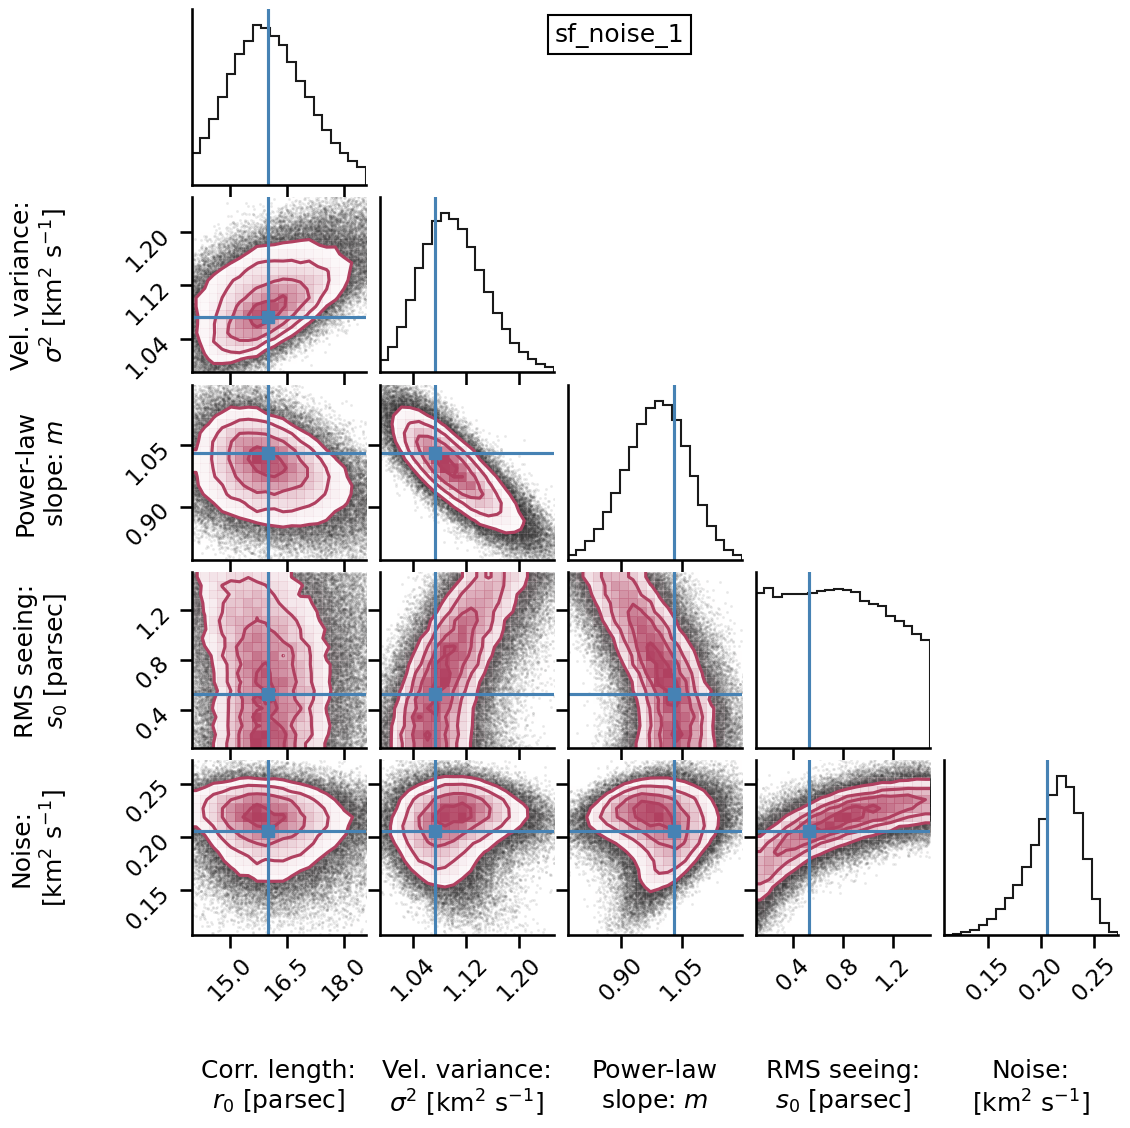

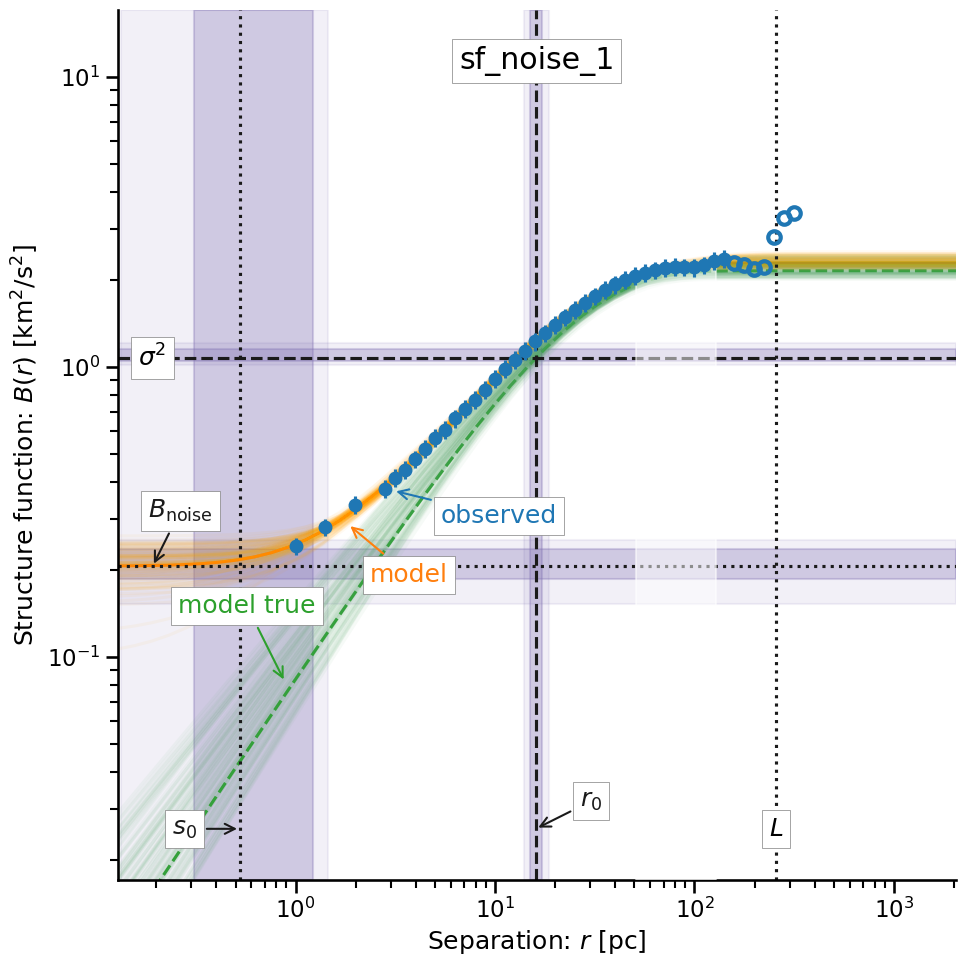

In [181]:
results = fit_structure_function(sf_noise_1, N=256, bfunc=bfunc, bplot=bplot, name = 'sf_noise_1', data = 'sf_noise_1')

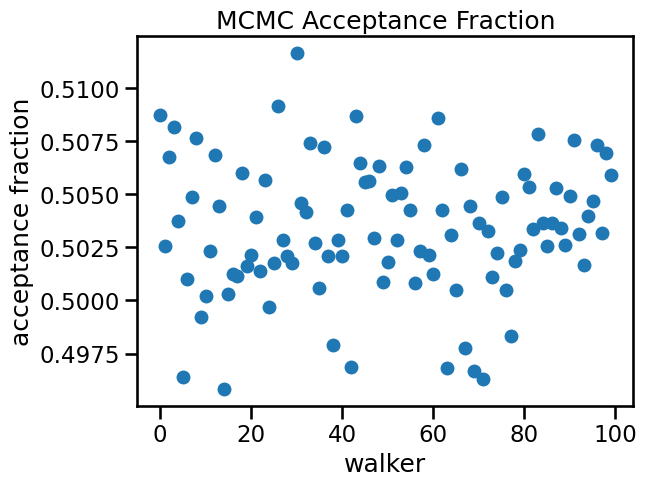

Autocorrelation time for the parameters:
----------------------------------------
r0 = 67.710
sig2 = 72.325
m = 71.318
s0 = 84.276
noise = 80.906


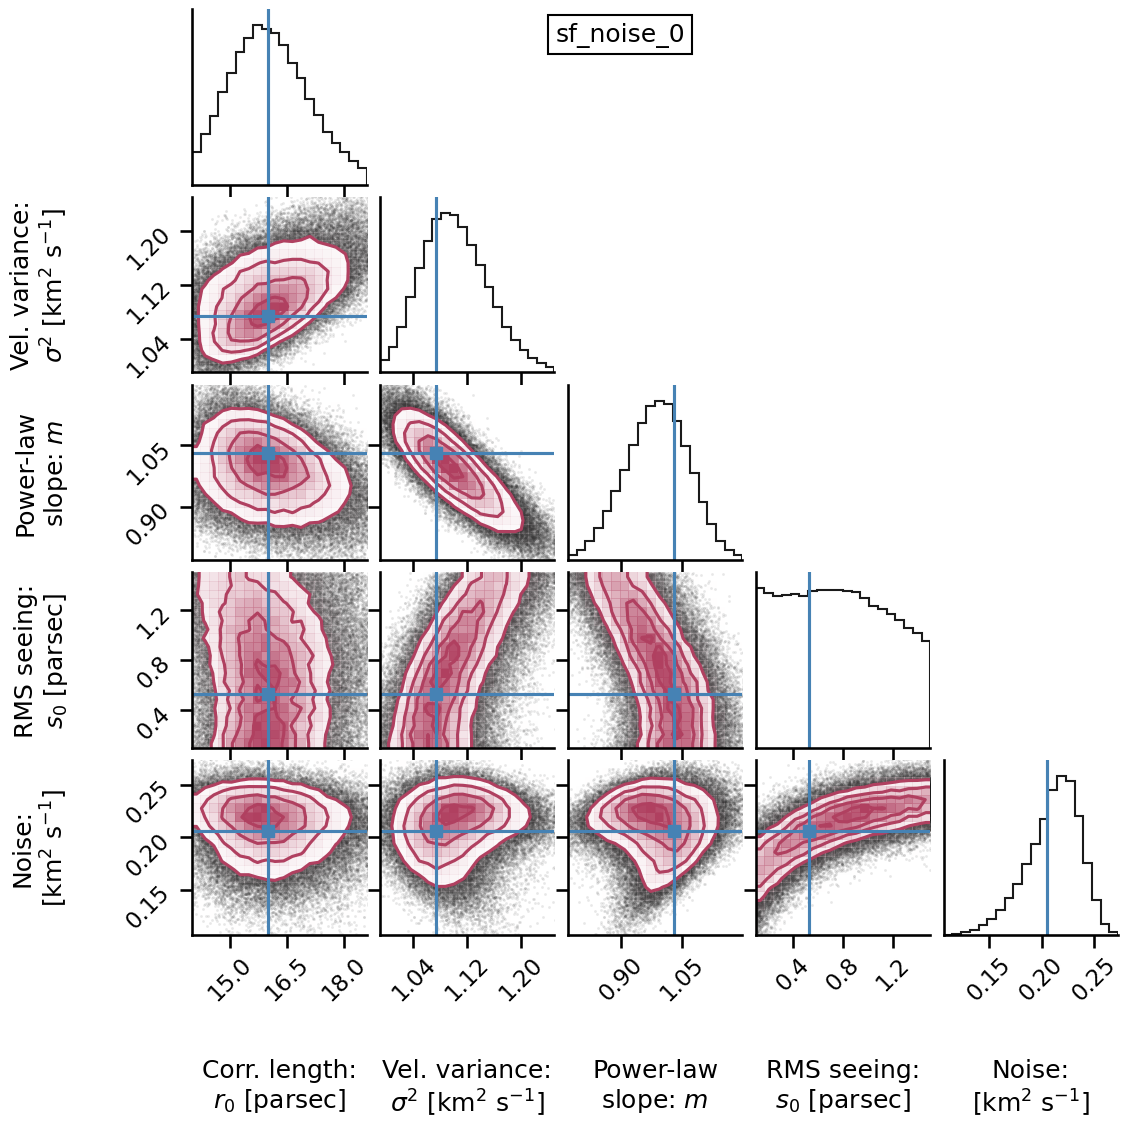

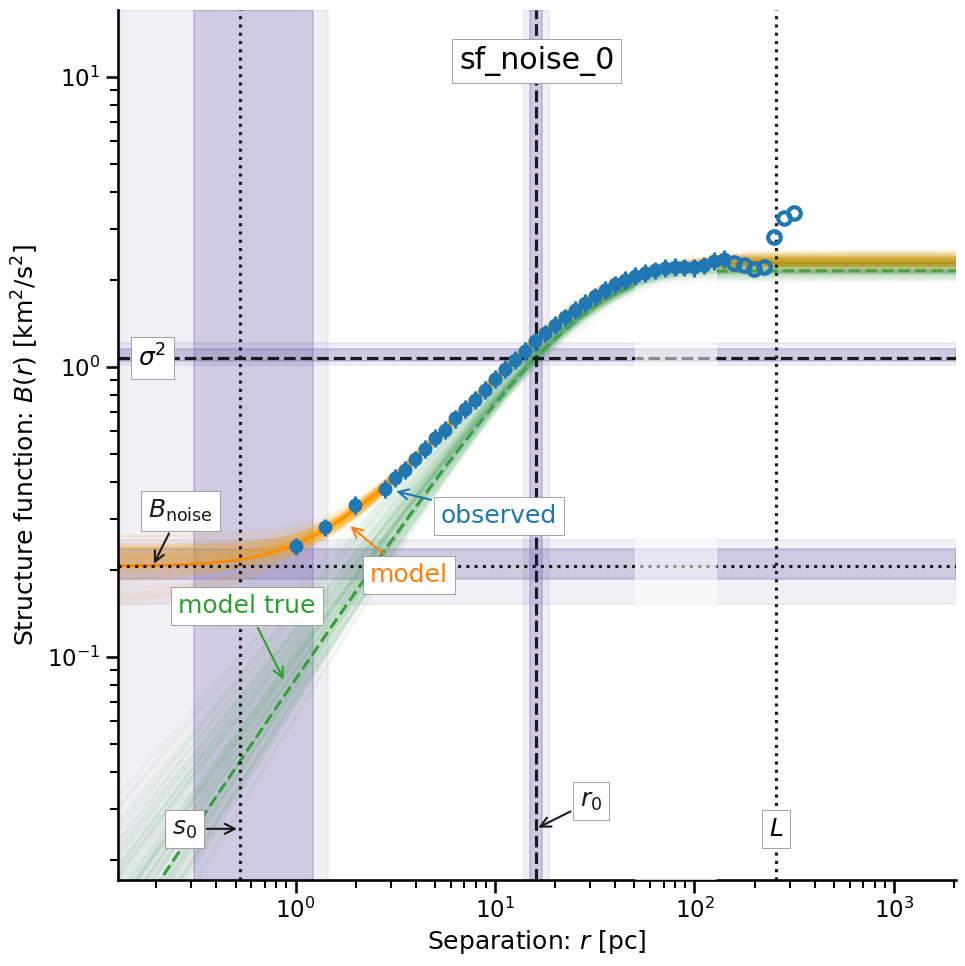

In [182]:
results = fit_structure_function(sf_noise_1, N=256, bfunc=bfunc, bplot=bplot, name = 'sf_noise_0', data = 'sf_noise_0')

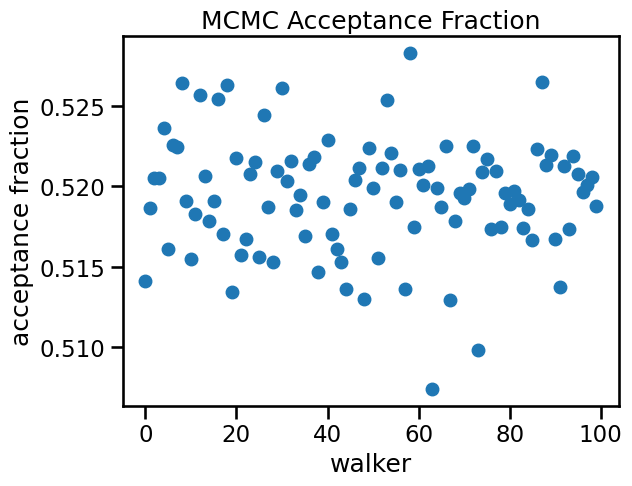

Autocorrelation time for the parameters:
----------------------------------------
r0 = 65.608
sig2 = 68.710
m = 69.330
s0 = 79.805
noise = 97.462


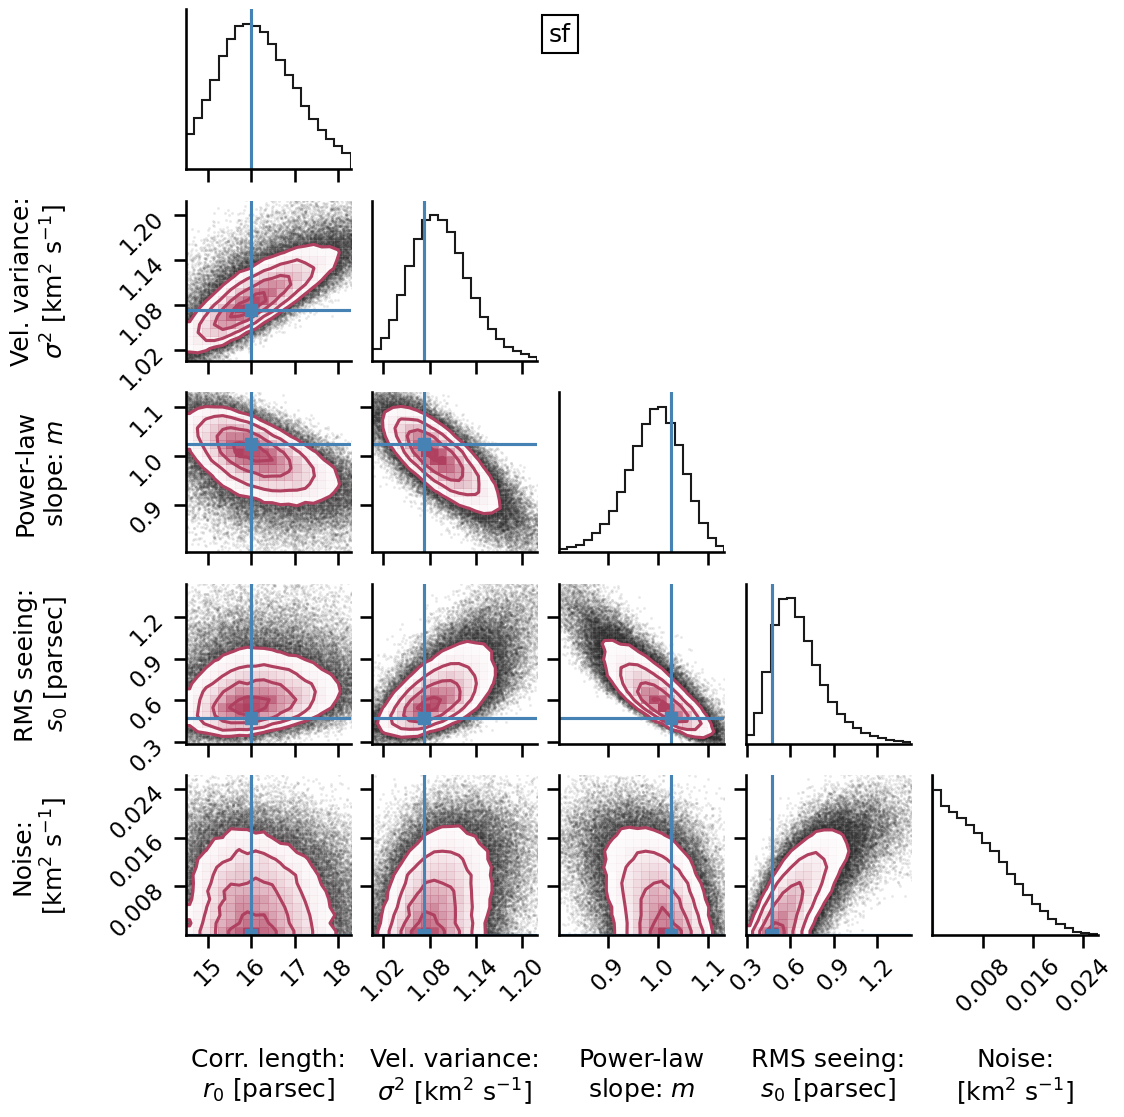

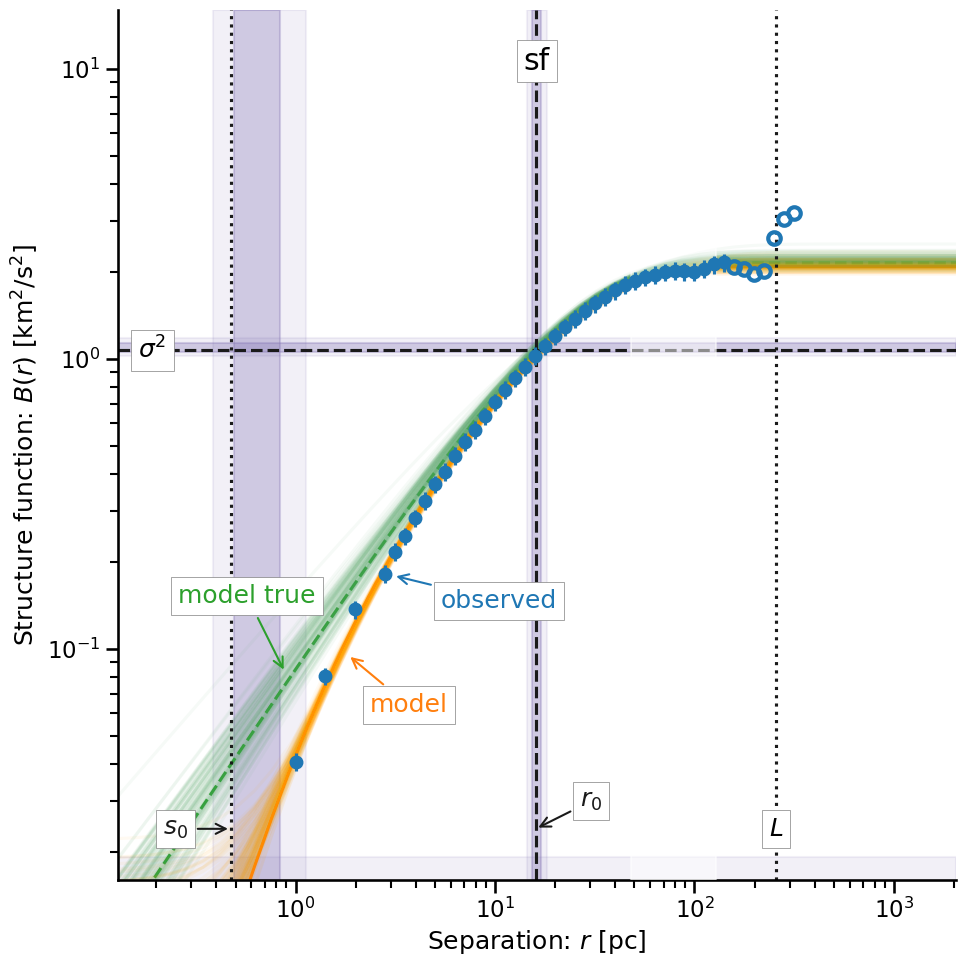

In [178]:
results = fit_structure_function(sf, N=256, bfunc=bfunc, bplot=bplot, name = 'sf', data = 'sf')

# confidence intervals

In [100]:
import lmfit

In [116]:
model = lmfit.Model(bfunc.bfunc03s)
model.param_names

['r0', 'sig2', 'm', 's0', 'noise']

In [117]:
mask = np.array(sf_noise_2["N pairs"]) > 0
B = np.array(sf_noise_2['Unweighted B(r)'])[mask]
r = np.array(10**sf_noise_2['log10 r'])[mask]
pc = 1
pix = 1
box_size = N
pc_per_arcsec = 1

In [118]:

# Correlation length between 1/10 and 2 x box_size
model.set_param_hint("r0", value=0.1 * box_size, min=0.01 * box_size, max=2.0 * box_size)

# sig2 between 1/4 and 2 x max value of B(r)
model.set_param_hint("sig2", value=0.5 * B.max(), min=0.25 * B.max(), max=2.0 * B.max())

# m between 1/2 and 5/3
model.set_param_hint("m", value=1.0, min=0.5, max=2.0)

# Seeing RMS between 0.1 and 1.5 arcsec
model.set_param_hint(
    "s0", value=0.5 * pc_per_arcsec, min=0.1 * pc_per_arcsec, max=1.5 * pc_per_arcsec
)

# Noise cannot be much larger than smallest B(r)
model.set_param_hint("noise", value=0.5 * B.min(), min=0.0, max=3 * B.min())

# box_size is fixed
# model.set_param_hint("box_size", value=box_size, vary=False)

In [119]:
pd.DataFrame(model.param_hints)

,r0,sig2,m,s0,noise
value,25.60,0.840870,1.0,0.5,0.650842
min,2.56,0.420435,0.5,0.1,0.000000
max,512.00,3.363479,2.0,1.5,3.905049


In [120]:
relative_uncertainty = 0.07
weights = 1.0 / (relative_uncertainty * B)
large_scale = r > 0.5* box_size
#weights[large_scale] /= 1.25
#weights[:1] /= 2.0



In [121]:
to_fit = r <= 0.6 * box_size
#to_fit = ~large_scale
result = model.fit(B[to_fit], weights=weights[to_fit], r=r[to_fit])

In [122]:
result

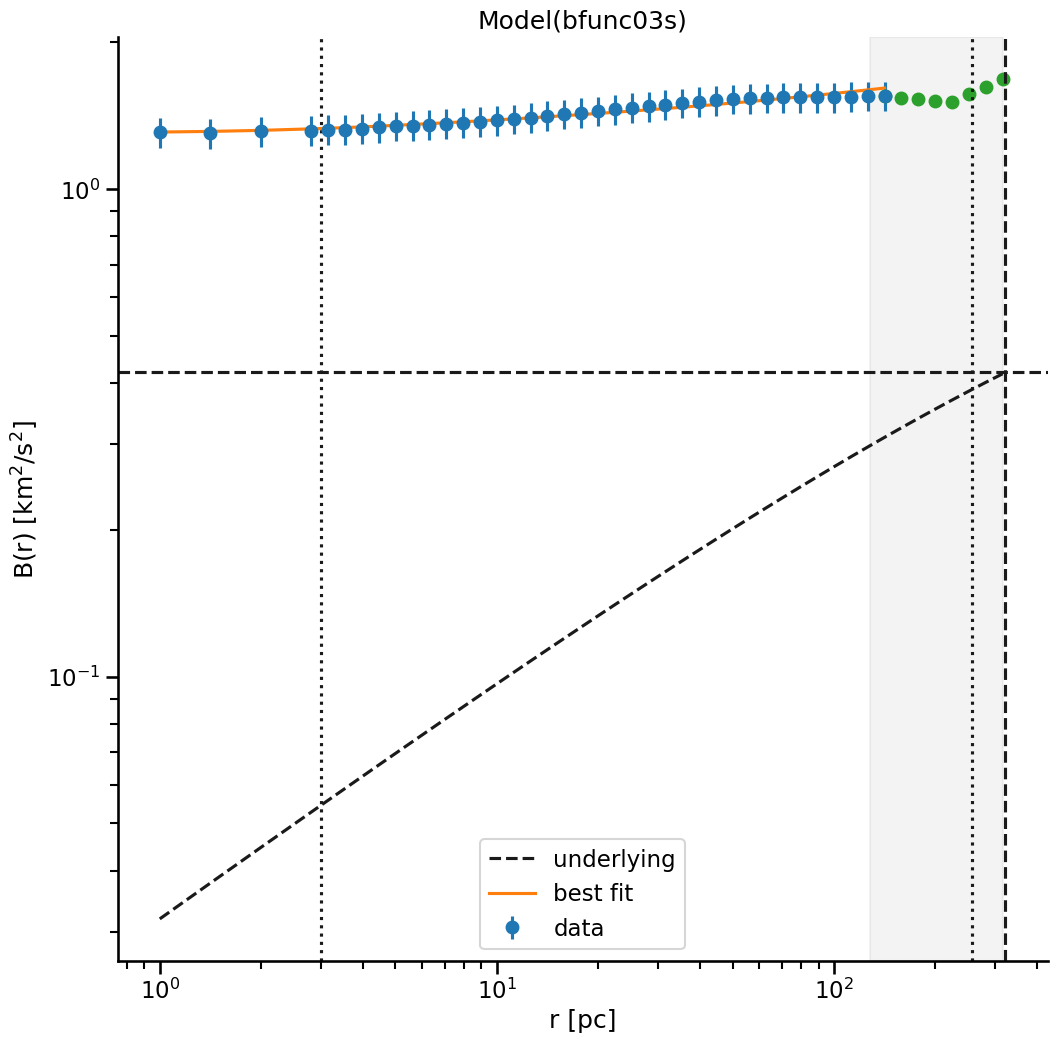

In [123]:


fig, ax = plt.subplots(figsize=(12, 12))

# Plot the underlying model without instrumental effects
Bu = bfunc.bfunc00s(
    r, result.params["r0"].value, result.params["sig2"].value, result.params["m"].value
)
ax.plot(r, Bu, color="k", linestyle="dashed", label="underlying")

# Plot the fit results
result.plot_fit(ax=ax)

# Add in the points not included in fit
ax.plot(r[large_scale], B[large_scale], "o")

# Dotted lines for 2 x rms seeing and for box size
ax.axvline(2 * result.params["s0"].value, color="k", linestyle="dotted")
ax.axvline(box_size, color="k", linestyle="dotted")

# Dashed lines for best-fit r0 and sig2
ax.axvline(result.params["r0"].value, color="k", linestyle="dashed")
ax.axhline(result.params["sig2"].value, color="k", linestyle="dashed")

# Gray box to indicate the large scale values that are excluded from the fit
ax.axvspan(box_size / 2, r[-1], color="k", alpha=0.05, zorder=-1)

ax.set(
    xscale="log",
    yscale="log",
    xlabel="r [pc]",
    ylabel=r"B(r) [km$^{2}$/s$^{2}$]",
)
sns.despine()



In [124]:


emcee_kws = dict(
    steps=50000, burn=500, thin=50, is_weighted=True, progress=False, workers=16
)
emcee_params = result.params.copy()
# emcee_params.add('__lnsigma', value=np.log(0.1), min=np.log(0.001), max=np.log(2.0))



In [125]:
result_emcee = model.fit(
    data=B[to_fit],
    r=r[to_fit],
    weights=weights[to_fit],
    params=emcee_params,
    method="emcee",
    nan_policy="omit",
    fit_kws=emcee_kws,
)

C:\Users\ZAINTEL2\anaconda3\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


In [126]:
result_emcee

Text(0, 0.5, 'acceptance fraction')

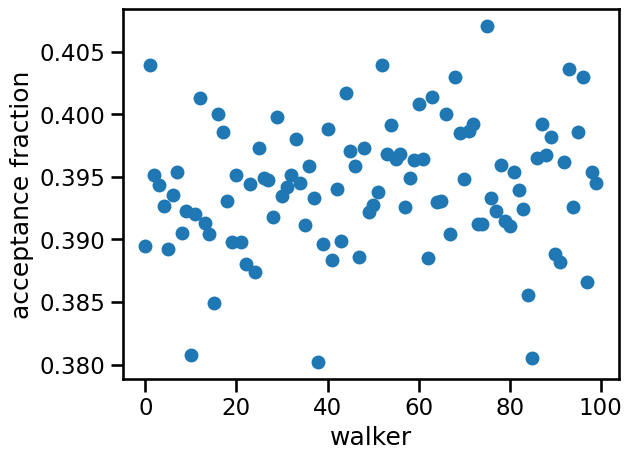

In [127]:
plt.plot(result_emcee.acceptance_fraction, "o")
plt.xlabel("walker")
plt.ylabel("acceptance fraction")

In [128]:
if hasattr(result_emcee, "acor"):
    print("Autocorrelation time for the parameters:")
    print("----------------------------------------")
    for i, p in enumerate(result_emcee.params):
        try:
            print(f"{p} = {result_emcee.acor[i]:.3f}")
        except IndexError:
            pass

Autocorrelation time for the parameters:
----------------------------------------
r0 = 134.782
sig2 = 167.657
m = 156.861
s0 = 121.577
noise = 134.174


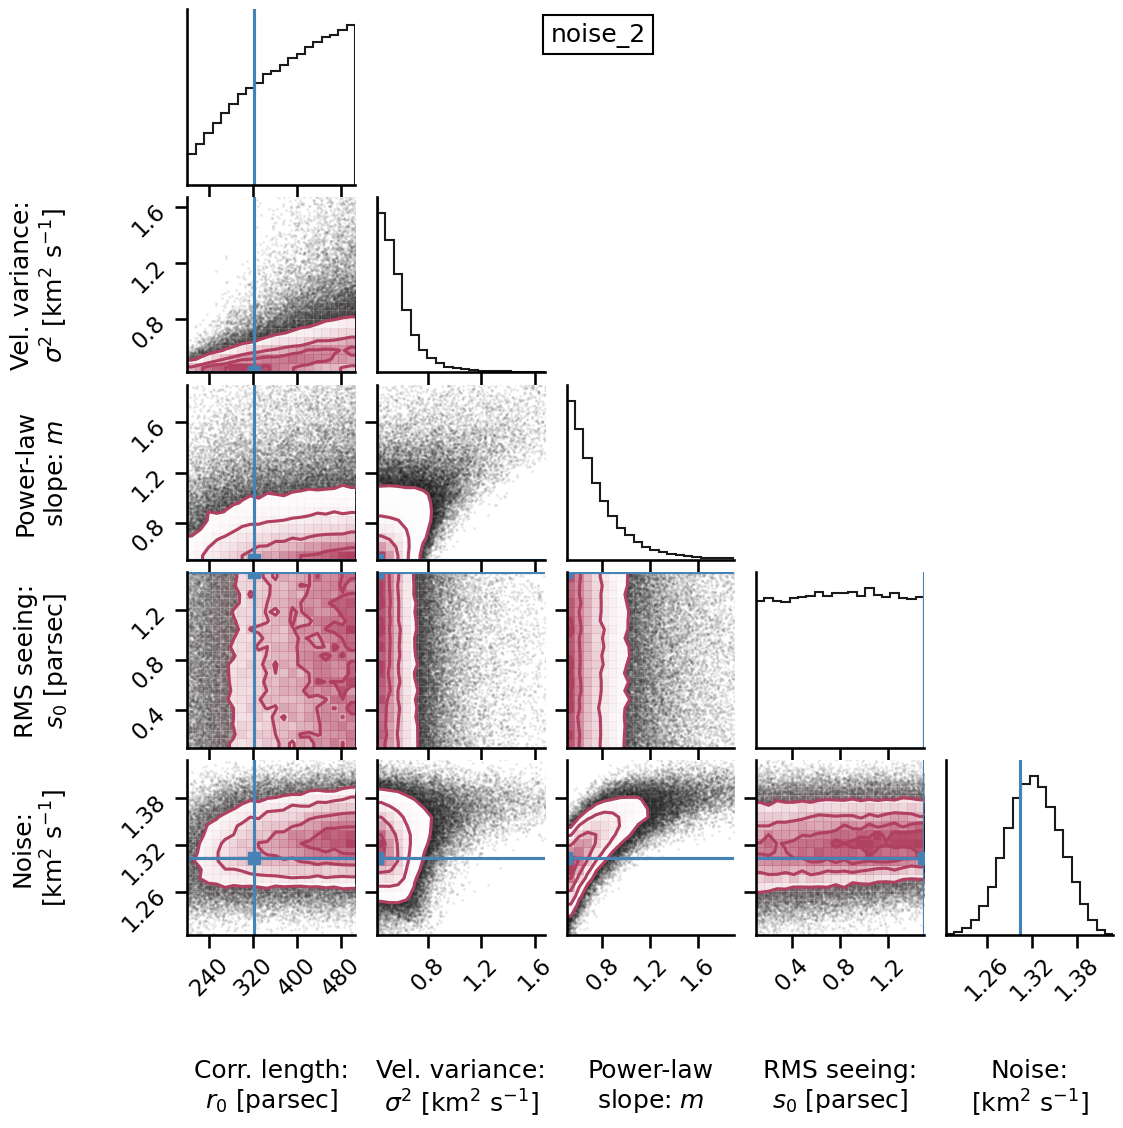

In [129]:
name =  'noise_2'
data = 'noise_2'

bplot.corner_plot(
    result_emcee, result, name, data, data_ranges=[0.95, 0.99, 0.995, 0.997, 0.999]
)
# data_ranges=[0.95, 0.99, 0.995, 0.995, 0.999]



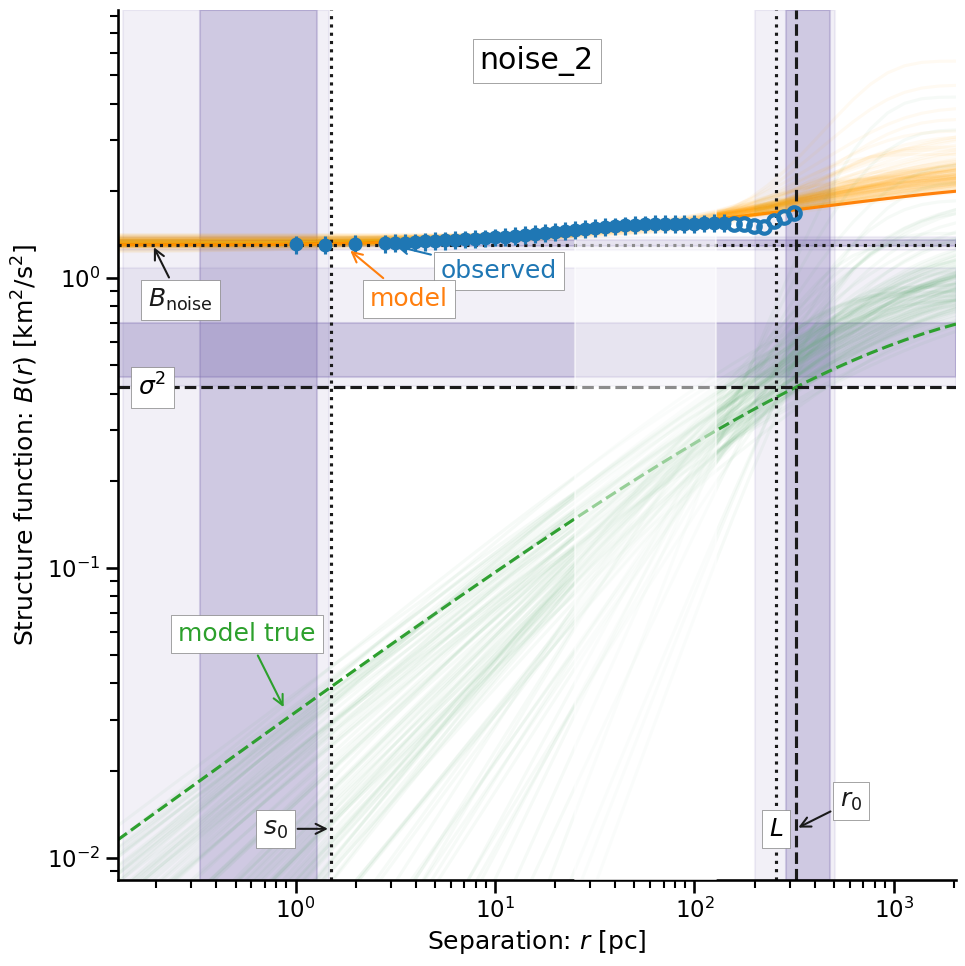

In [130]:


bplot.strucfunc_plot(
    result_emcee, result, r, B, to_fit, name, data, box_size, large_scale
)

